# <center>**Theta Residues**<center>

**Libraries**

In [1]:
import numpy as np
import mbloodmoon.iros_management as iros
import mbloodmoon as bm

from _IROS_support import _handle_dirpaths

In [2]:
mask_FITS = "wfm_mask.fits"

skyfield = "GalacticCenter"
#data_FITS = "20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb"
data_FITS = "20250320_galctr_rxte_sax_2-50keV_1ks_sources_cxb_infmaskdet"
#data_FITS = "20250131_galctr_rxte_sax_2-30keV_1ks_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_realmask_infdet_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_opaquemask_realdet_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_thinmask_realdet_sources_cxb"


#skyfield = "Crab"
#data_FITS = "20250227_crab_cxb_2-50keV_1ks"


N_TEST = "test_vignetting"
#N_TEST = "test_vignetting_opposite_cut"

UPX, UPY = 5, 1

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    test_name=N_TEST,
)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = "reconstructed"

filepaths = bm.simulation_files(simul_data)
energy_range = (2, 30)
coords = None


from temp_camera import codedmask

wfm = codedmask(mask_path, UPX, UPY)
sdlA = bm.simulation(filepaths[cam_a][dataset], energy_range=energy_range, coords=coords)
sdlB = bm.simulation(filepaths[cam_b][dataset], energy_range=energy_range, coords=coords)

catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])

In [3]:
mask_path, simul_data, save_path

('/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/wfm_mask.fits',
 '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/GalacticCenter/20250320_galctr_rxte_sax_2-50keV_1ks_sources_cxb_infmaskdet/',
 '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Outputs/OutGalacticCenter/20250320_galctr_rxte_sax_2-50keV_1ks_sources_cxb_infmaskdet/test_vignetting/')

In [4]:
database_name = save_path + f"IROS_sources_database_TEST_{N_TEST}.fits"
database = iros.load_iros_data(database_name)

# Loading data...
# Loading completed!


In [5]:
from copy import deepcopy
from pandas import DataFrame

from mbloodmoon.io import SimulationDataLoader
from mbloodmoon.mask import CodedMaskCamera
from mbloodmoon.coords import equatorial2shift, shift2theta


def get_catalog_theta(
    data: dict,
    catalogs: tuple[np.recarray],
    sdls: tuple[SimulationDataLoader],
    camera: CodedMaskCamera,
) -> DataFrame:
    """Returns catalog sources respective camera angular coordinates."""
    db = {
        cameraID: deepcopy({
            "theta_x": [],
            "theta_y": [],
        })
        for cameraID in data.keys()
    }

    for sdl, cat, cameraID in zip(
        sdls, catalogs, data.keys(),
    ):
        print(f"# Checking {cameraID.upper()}...")
        for name in data[cameraID]["catalog_name"]["data"]:
            cat_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
            cat_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
            sx, sy = equatorial2shift(sdl, camera, cat_ra, cat_dec)
            db[cameraID]["theta_x"].append(shift2theta(camera, sx))
            db[cameraID]["theta_y"].append(shift2theta(camera, sy))

    return iros.dict2df(db)



catalog_theta = get_catalog_theta(database, (catalogA, catalogB), (sdlA, sdlB), wfm)

# Checking CAM1A...
# Checking CAM1B...


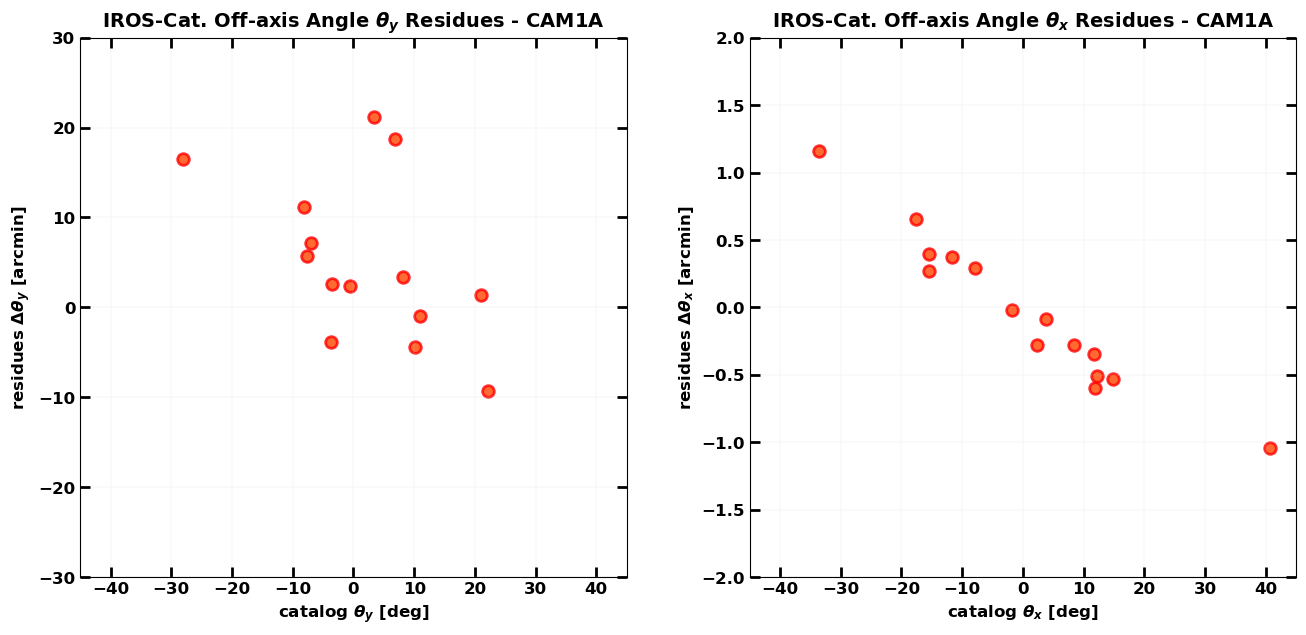

In [6]:
# CAM1A
thetay_cam1a = database[cam_a]["theta_y"]["data"]
thetax_cam1a = database[cam_a]["theta_x"]["data"]

thetay_catalog_cam1a = catalog_theta[cam_a]["theta_y"]
thetax_catalog_cam1a = catalog_theta[cam_a]["theta_x"]

iros.plot_sequence(
    input_sequence=[60 * (thetay_cam1a - thetay_catalog_cam1a), 60 * (thetax_cam1a - thetax_catalog_cam1a)],
    title=[r"IROS-Cat. Off-axis Angle $\theta_{y}$ Residues - CAM1A", r"IROS-Cat. Off-axis Angle $\theta_{x}$ Residues - CAM1A"],
    x=[thetay_catalog_cam1a, thetax_catalog_cam1a],
    xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
    ylabel=[r"residues $\Delta\theta_{y}$" + " [arcmin]", r"residues $\Delta\theta_{x}$" + " [arcmin]"],
    style=["scatter"]*2,
    offsetx=[(-45, 45)]*2,
    offsety=[(-30, 30), (-2, 2)],
)

In [7]:
## CAM1B
#thetay_cam1b = database[cam_b]["theta_y"]["data"]
#thetax_cam1b = database[cam_b]["theta_x"]["data"]
#
#thetay_catalog_cam1b = catalog_theta[cam_b]["theta_y"]
#thetax_catalog_cam1b = catalog_theta[cam_b]["theta_x"]
#
#iros.plot_sequence(
#    input_sequence=[60 * (thetay_cam1b - thetay_catalog_cam1b), 60 * (thetax_cam1b - thetax_catalog_cam1b)],
#    title=[r"IROS-Cat. Off-axis Angle $\theta_{y}$ Residues - CAM1B", r"IROS-Cat. Off-axis Angle $\theta_{x}$ Residues - CAM1B"],
#    x=[thetay_catalog_cam1b, thetax_catalog_cam1b],
#    xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
#    ylabel=[r"residues $\Delta\theta_{y}$" + " [arcmin]", r"residues $\Delta\theta_{x}$" + " [arcmin]"],
#    style=["scatter"]*2,
#    offsetx=[(-45, 45)]*2,
#    offsety=[(-22, 22), (-2, 2)],
#)

In [8]:
res_sky_camA, _ = iros.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{N_TEST}.fits")
res_sky_camB, _ = iros.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


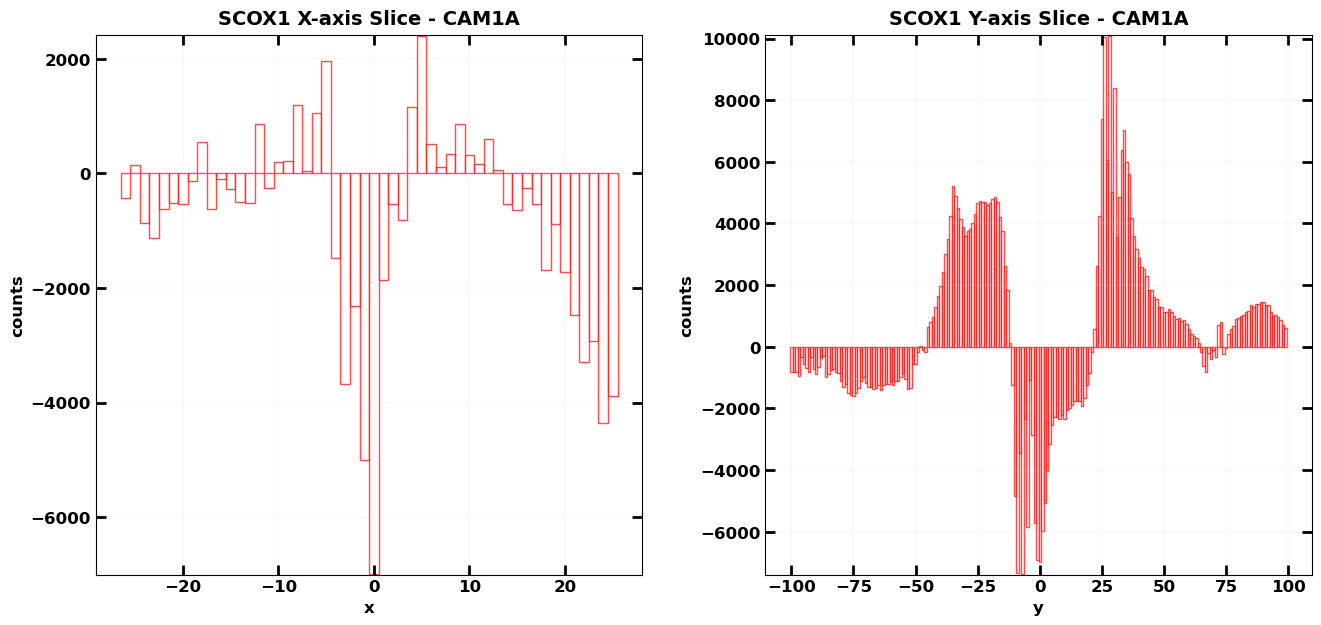

In [9]:
# CAM1A
_to = 1

for source, y, x in zip(
    database[cam_a]["catalog_name"]["data"][:_to],
    database[cam_a]["y"]["data"][:_to],
    database[cam_a]["x"]["data"][:_to],
):
    iros.enhance_slices(
        sky=res_sky_camA,
        pos=(y, x),
        crp=(int(50 * (1 + UPY)), int(10 * (1 + UPX / 3))),
        source=source,
        cameraID=cam_a,
    )

In [10]:
## CAM1B
#_to = 1
#
#for source, y, x in zip(
#    database[cam_b]["catalog_name"]["data"][:_to],
#    database[cam_b]["y"]["data"][:_to],
#    database[cam_b]["x"]["data"][:_to],
#):
#    iros.enhance_slices(
#        sky=res_sky_camB,
#        pos=(y, x),
#        crp=(int(50 * (1 + UPY)), int(10 * (1 + UPX / 3))),
#        source=source,
#        cameraID=cam_b,
#    )